In [10]:
import numpy as np
import matplotlib.pyplot as plt
from utils import *
from stimugenerator import dataIO
from scipy.interpolate import interp1d

In [2]:
hSML_dict = dataIO.unPickle("./opsins/human_SML_valid_NM.pkl")
print(hSML_dict.keys())
sts_nm = np.load('opsins/STS_nm.npy')

dict_keys(['s', 'm', 'l', 'nm', 'idx', 'sts_nm', 'sts_idx'])


In [3]:
sts_overlap_nm = hSML_dict['sts_nm'];print(sts_overlap_nm.shape)
sts_overlap_idx = hSML_dict['sts_idx']
opsin_overlap_nm = hSML_dict['nm'];print(opsin_overlap_nm.shape)
opsin_overlap_idx = hSML_dict['idx'];print(opsin_overlap_idx.shape)
red = hSML_dict['l']
green = hSML_dict['m']
blue = hSML_dict['s']
red_monitor = np.load("./opsins/monitor_red_630.npy")[opsin_overlap_idx]
print(red_monitor.shape)

(682,)
(887,)
(2048,)
(887,)


In [4]:
def vline_max(x,y,c,l='solid'):
    max_nm = x[np.argmax(y)]
    label_nm = int(max_nm)
    plt.vlines(max_nm,0,1,color=c,label='{} nm'.format(label_nm),linestyle=l)

## inspect the human opsin files

Text(0.5, 1.0, 'human opsin in the overlap wavelength area')

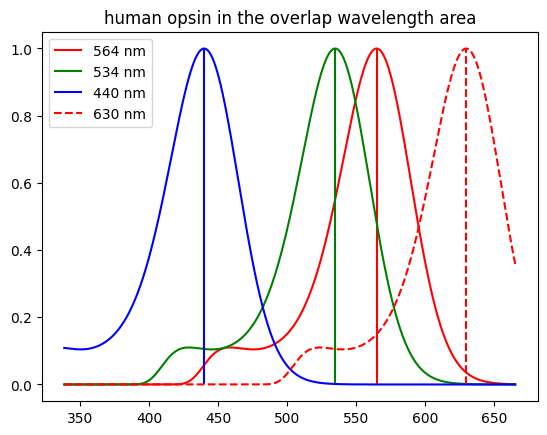

In [5]:
plt.plot(opsin_overlap_nm,red,color='r')
vline_max(opsin_overlap_nm,red,'r')
plt.plot(opsin_overlap_nm,green,color='g')
vline_max(opsin_overlap_nm,green,'g')
plt.plot(opsin_overlap_nm,blue,color='blue')
vline_max(opsin_overlap_nm,blue,'blue')
plt.plot(opsin_overlap_nm,red_monitor,color='r',linestyle='dashed')
vline_max(opsin_overlap_nm,red_monitor,'r','dashed')
plt.legend()
plt.title("human opsin in the overlap wavelength area")

## inspect recordings from STS

In [6]:
pure_ = np.load("./darkRoom_255RGB_2407_pure.npy") ## recording of a RGB printout, 0:red -> ?:green,->-1:blue
print(pure_.shape)

(15, 1024)


In [7]:
pure = pure_[:,sts_overlap_idx]
print(pure.shape)

(15, 682)


In [19]:
opsin_overlap_nm.shape

(887,)

In [23]:
opsin_red_interp = interp1d(opsin_overlap_nm,red)
opsin_green_interp = interp1d(opsin_overlap_nm,green)
opsin_blue_interp = interp1d(opsin_overlap_nm,blue)
opsin_red_monitor_interp = interp1d(opsin_overlap_nm,red_monitor)

In [26]:
opsin2sts_red= opsin_red_interp(sts_overlap_nm)
opsin2sts_green= opsin_green_interp(sts_overlap_nm)
opsin2sts_blue= opsin_blue_interp(sts_overlap_nm)
opsin2sts_red_monitor= opsin_red_monitor_interp(sts_overlap_nm)

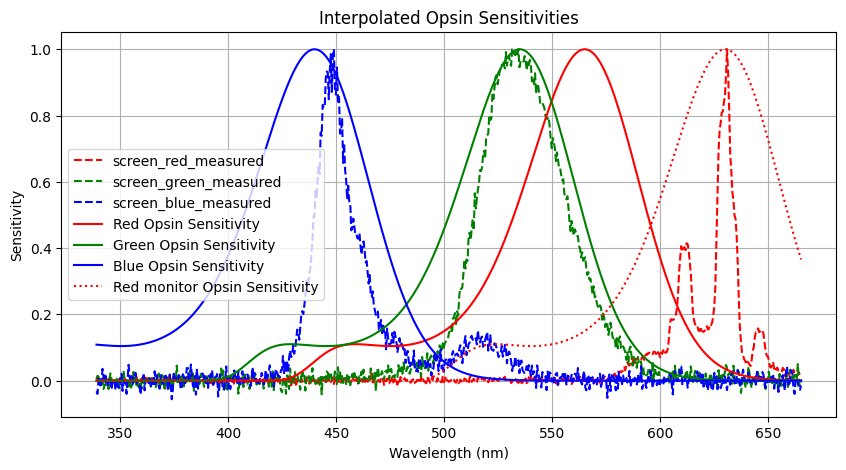

In [27]:
plt.figure(figsize=(10, 5))

plt.plot(sts_overlap_nm,pure[5]/np.max(pure[5]),color='r',label='screen_red_measured',linestyle='dashed')
plt.plot(sts_overlap_nm,pure[10]/np.max(pure[10]),color='green',label='screen_green_measured',linestyle='dashed')
plt.plot(sts_overlap_nm,pure[-1]/np.max(pure[-1]),color='blue',label='screen_blue_measured',linestyle='dashed')
plt.legend()

plt.plot(sts_overlap_nm, opsin2sts_red, label='Red Opsin Sensitivity',color='r')
plt.plot(sts_overlap_nm, opsin2sts_green, label='Green Opsin Sensitivity',color='g')
plt.plot(sts_overlap_nm, opsin2sts_blue, label='Blue Opsin Sensitivity',color='blue')
plt.plot(sts_overlap_nm,opsin2sts_red_monitor,label='Red monitor Opsin Sensitivity',color='r',linestyle='dotted')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Sensitivity')
plt.title('Interpolated Opsin Sensitivities')
plt.legend()
plt.grid(True)
plt.show()

## color matching 

In [31]:
sts_overlap_nm.shape

(682,)

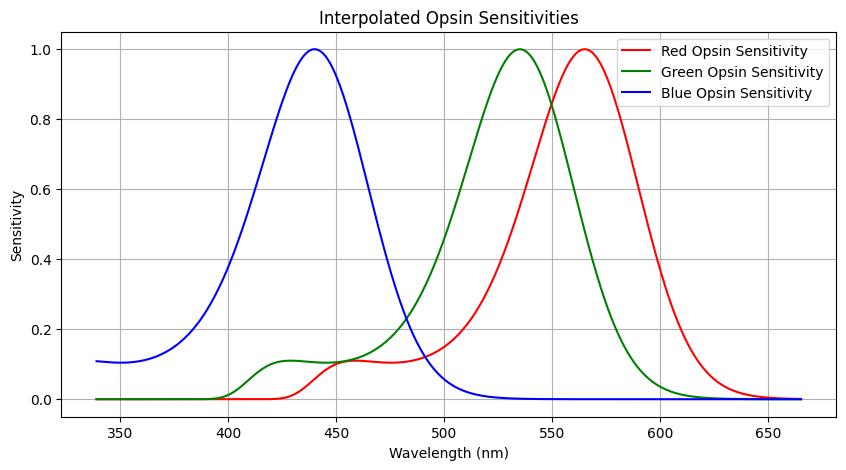

In [32]:
# Plot the interpolated opsin sensitivities to verifycreate the RGB pattern using
plt.figure(figsize=(10, 5))
plt.plot(sts_overlap_nm,opsin2sts_red, label='Red Opsin Sensitivity',color='r')
plt.plot(sts_overlap_nm, opsin2sts_green, label='Green Opsin Sensitivity',color='g')
plt.plot(sts_overlap_nm, opsin2sts_blue, label='Blue Opsin Sensitivity',color='blue')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Sensitivity')
plt.title('Interpolated Opsin Sensitivities')
plt.legend()
plt.grid(True)
plt.show()


In [33]:
spectral_data = np.copy(pure)

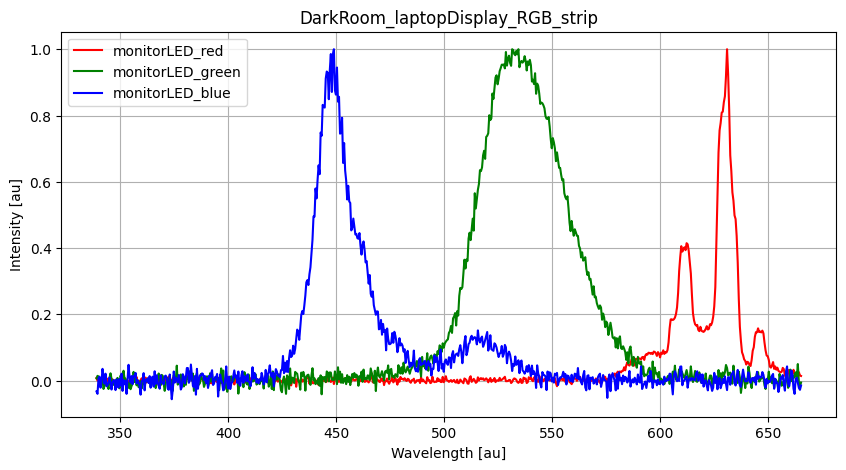

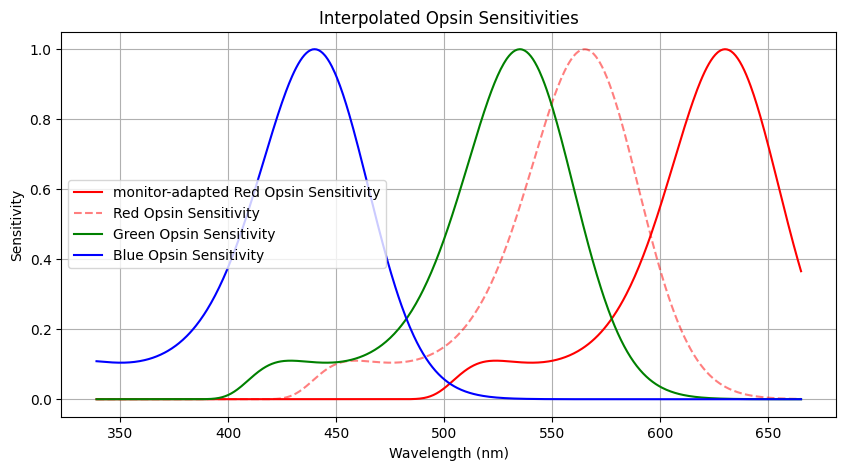

In [140]:
# Plot the interpolated opsin sensitivities to verify
plt.figure(figsize=(10, 5))
plt.plot(sts_overlap_nm, spectral_data[5]/np.max(spectral_data[5]), label='monitorLED_red',color='r')
plt.plot(sts_overlap_nm, spectral_data[10]/np.max(spectral_data[10]),label='monitorLED_green',color='g')
plt.plot(sts_overlap_nm, spectral_data[-1]/np.max(spectral_data[-1]), label='monitorLED_blue',color='blue')
plt.xlabel('Wavelength [au]')
plt.ylabel('Intensity [au]')
plt.title('DarkRoom_laptopDisplay_RGB_strip')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))

plt.plot(sts_overlap_nm, opsin2sts_red_monitor, label='monitor-adapted Red Opsin Sensitivity',color='r')
plt.plot(sts_overlap_nm, opsin2sts_red, label='Red Opsin Sensitivity',color='r',linestyle='dashed',alpha=.5)

plt.plot(sts_overlap_nm, opsin2sts_green, label='Green Opsin Sensitivity',color='g')
plt.plot(sts_overlap_nm, opsin2sts_blue, label='Blue Opsin Sensitivity',color='blue')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Sensitivity')
plt.title('Interpolated Opsin Sensitivities')
plt.legend()

plt.grid(True)
plt.show()

In [72]:
# Compute RGB values using the interpolated opsin sensitivities
def spectral_to_rgb_sum(spectral_data, opsin_red, opsin_green, opsin_blue):
    R = np.sum(spectral_data * opsin_red, axis=-1)
    G = np.sum(spectral_data * opsin_green, axis=-1)
    B = np.sum(spectral_data * opsin_blue, axis=-1)
    return R, G, B

In [88]:
# Compute RGB values using the interpolated opsin sensitivities
def spectral_to_rgb_multi(spectral_data, opsin2sts_red, opsin2sts_green, opsin2sts_blue):
    R = np.matmul(spectral_data,opsin2sts_red)
    G = np.matmul(spectral_data,opsin2sts_green)
    B = np.matmul(spectral_data,opsin2sts_blue)
    return R, G, B

In [89]:
# Load spectral data
spectral_data = np.load("./darkRoom_255RGB_2407_pure.npy")[:,sts_overlap_idx]
# R, G, B = spectral_to_rgb(spectral_data, opsin2sts_red_monitor, opsin2sts_green, opsin2sts_blue)
R, G, B = spectral_to_rgb_multi(spectral_data, opsin2sts_red_monitor, opsin2sts_green, opsin2sts_blue)

In [99]:
R

array([   87.80028362,    88.99972469,   107.9506544 , 10184.34902996,
       10375.49112397, 10038.77486311, 10352.90637254, 10331.24715895,
        1974.26663523,  1942.18590849,  1760.33225042,  1789.37334561,
        1677.94017438,  1568.51047471,   114.75419748])

In [100]:
G

array([5.39579035e+01, 6.50173001e+01, 8.56455402e+00, 1.91189706e+02,
       1.56772105e+02, 2.23751317e+02, 3.22016635e+02, 3.88175868e+02,
       1.21402100e+04, 1.19218737e+04, 1.14005536e+04, 1.12333008e+04,
       1.08691588e+04, 1.01045510e+04, 1.47074419e+03])

In [101]:
B

array([  69.61042539,    5.79057951,   24.15422018,   69.11841412,
         31.31174375,   51.65238237,   96.84483359,   25.5789999 ,
        222.08775633,  202.18876866,  204.30923855,  195.66354851,
        275.93985597,  325.3003196 , 4846.34886691])

In [98]:
# Stack RGB values to form the RGB image
RGB = np.stack([R, G, B], axis=-1)
RGB = RGB/255.
RGB[-1]

array([ 0.45001646,  5.76762427, 19.00528967])

In [102]:
# Normalize the RGB values
R_norm = R / np.max(R)
G_norm = G / np.max(G)
B_norm = B / np.max(B)

# Stack RGB values to form the RGB image
RGB = np.stack([R_norm, G_norm, B_norm], axis=-1)

In [121]:
from matplotlib.pyplot import figure


Text(0.5, 1.0, 'Reconstructed')

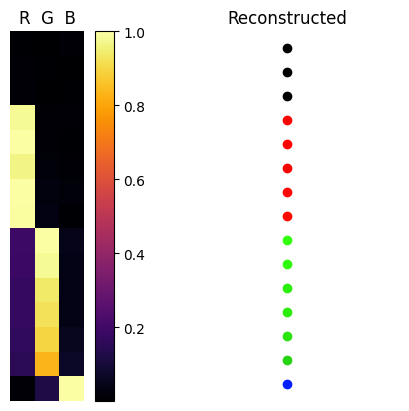

In [145]:
# Display the RGB image
plt.subplot(121)
ax1=plt.imshow(RGB,cmap='inferno')
cb=plt.colorbar(ax1)
plt.axis('off')
plt.title('R  G  B')

plt.subplot(122)
for i in range(len(spectral_data)):
    plt.scatter(1,len(spectral_data)-i,color=RGB[i])
plt.axis('off')
plt.title('Reconstructed')

Text(0.5, 1.0, 'Reconstructed')

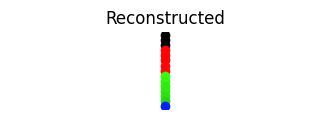

In [127]:
plt.figure(figsize=(4, 1))
for i in range(len(spectral_data)):
    plt.scatter(1,len(spectral_data)-i,color=RGB[i])
plt.annotate('dark area',(14,0.98))
plt.axis('off')
plt.title('Reconstructed')

In [84]:
R

array([   87.80028362,    88.99972469,   107.9506544 , 10184.34902996,
       10375.49112397, 10038.77486311, 10352.90637254, 10331.24715895,
        1974.26663523,  1942.18590849,  1760.33225042,  1789.37334561,
        1677.94017438,  1568.51047471,   114.75419748])

### just in case, overlap meaning

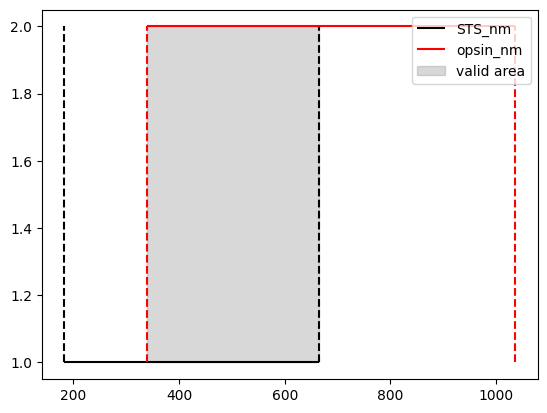

In [51]:
plt.hlines(1,np.min(sts_nm),np.max(sts_nm),color='k',label='STS_nm')
plt.vlines(np.min(sts_nm),1,2,color='k',linestyle='dashed')
plt.vlines(np.max(sts_nm),1,2,color='k',linestyle='dashed')

plt.hlines(2,np.min(opsin_nm),np.max(opsin_nm),color='r',label='opsin_nm')
plt.vlines(np.min(opsin_nm),1,2,color='r',linestyle='dashed')
plt.vlines(np.max(opsin_nm),1,2,color='r',linestyle='dashed')

plthuman.fill_betweenx([1,2],np.min(opsin_nm),np.max(sts_nm),color='gray',alpha=.3,label='valid area')
plt.legend()